In [77]:
import random


states_dict = {
            "s0":  [0, 0] ,
            "s1":  [0, 1] ,
            "s2":  [0, 2] ,
            "s3":  [0, 3] ,
            "s4":  [0, 4] ,
            "s5":  [1, 0] ,
            "s6":  [1, 1] ,
            "s7":  [1, 2] ,
            "s8":  [1, 3] ,
            "s9":  [1, 4] ,
            "s10":  [2, 0] ,
            "s11":  [2, 1] ,
            "s12":  [2, 2] ,
            "s13":  [2, 3] ,
            "s14":  [2, 4] ,
            "s15":  [3, 0] ,
            "s16":  [3, 1] ,
            "s17":  [3, 2] ,
            "s18":  [3, 3] ,
            "s19":  [3, 4] ,
            "s20":  [4, 0] ,
            "s21":  [4, 1] ,
            "s22":  [4, 2] ,
            "s23":  [4, 3] ,
            "s24":  [4, 4] ,
}

terminal_states_dict = ["s0","s24"]

In [78]:



#Blueprint

#Environment

states = [
    [0, 0], [0, 1], [0, 2], [0, 3], [0, 4],
    [1, 0], [1, 1], [1, 2], [1, 3], [1, 4],
    [2, 0], [2, 1], [2, 2], [2, 3], [2, 4],
    [3, 0], [3, 1], [3, 2], [3, 3], [3, 4],
    [4, 0], [4, 1], [4, 2], [4, 3], [4, 4]
]


actions = ["L","R","U","D"]

reward = [-1,0]

#Transition

#p(s',r|s,a)
def transition_distribution(s,a): #given state s and an action a taken on it. . . 
    dist ={}
    #Returns a probability distribution for each state and respective reward
    return dist

#Policy π: s -> a, or π(a|s)
def policy(s): #given state s
    dist = {}

    #Returns a probability distribution for each action
    return dist

def Gt(tr,gamma): #Given a trajectory tr:[[s0,r0],[s1,r1],[s2,r2],. . .]

    gt = 0
    
    for i in range(len(tr)):

        gt = gt + pow(gamma,i) * tr[i][1]
    
    return gt #Returns Gt

def MDP(states,actions,reward,transition_distribution=transition_distribution,policy=policy,Gt=Gt):
    trajectory = []

    return trajectory



In [ ]:

#Blueprint

#-------------------------------------------------------------------
#Environment
states = [
    [0, 0], [0, 1], [0, 2], [0, 3], [0, 4],
    [1, 0], [1, 1], [1, 2], [1, 3], [1, 4],
    [2, 0], [2, 1], [2, 2], [2, 3], [2, 4],
    [3, 0], [3, 1], [3, 2], [3, 3], [3, 4],
    [4, 0], [4, 1], [4, 2], [4, 3], [4, 4]
]


terminal_states=[[0,0],[4,4],[2,2]]



#Deterministic
actions = {"L":[0,-1],
           "R":[0,1],
           "U":[-1,0],
           "D":[1,0]
           }


reward = [-1,0]

#-------------------------------------------------------------------

#-------------------------------------------------------------------
#Transition
#Initial state probability_distribution

def p_0(states=states,random_dist=True):
    if(random_dist):
        dist = {}
        for s in states:
            tup = tuple(s)
            dist[tup]=1/len(states)



        return dist

#p(s',r|s,a)
#We are going to make this deterministic
def transition_probability_distribution(s,a,states=states,actions=actions,reward=reward,terminal_states=terminal_states,debug=False,shows=""): #given state s and an action a taken on it. . . 
    dist ={}

    action_move = actions[a]
    if debug:
        print(f"type of s: {type(s)} s:{s}   ")

    next_state = [s[0] + action_move[0],s[1]+action_move[1]] #Deterministic because gives next state PRECISELY
    r = 0
    
    for i in terminal_states:
        if i==next_state:
            r = 0
            break
        r = -1
    key = (tuple(next_state),r)

    for i in states:
        for j in reward:
            if(key==(tuple(i),j)):
                dist[key]=1
            else:
                dist[(tuple(i),j)]=1e-20



    #Returns a probability distribution for each state and respective reward
    return dist

#Policy π: s -> a, or π(a|s)
def policy(s,pi_not=True): #given state s

    if pi_not:
        dist = {"L":0.25,
           "R":0.25,
           "U":0.25,
           "D":0.25
           }

    #Returns a probability distribution for each action
    return dist

def Gt(tr,gamma): #Given a trajectory tr:[[s0,r0],[s1,r1],[s2,r2],. . .]

    gt = 0
    
    for i in range(1,len(tr)):

        gt = gt + pow(gamma,i) * tr[i][1]
    
    return gt #Returns Gt




def MDP(states,actions,reward,transition_probability_distribution=transition_probability_distribution,policy=policy,s=[1,2],terminal_states=terminal_states,debug=False):


    action_distribution = policy(s)
    probable_actions= list(action_distribution.keys())
    probable_actions_probability = list(action_distribution.values())
    
    
    a=random.choices(probable_actions, probable_actions_probability)[0]

    transition_prob = transition_probability_distribution(s,a,states=states,reward=reward,actions=actions,terminal_states=terminal_states,debug=debug,shows="From MDP")
    probable_states = list(transition_prob.keys())
    probable_states_probability = list(transition_prob.values())

    s_r=random.choices(probable_states, probable_states_probability)[0]
    s_tuple=s_r[0]
    s_dash=list(s_tuple)


    r = s_r[1]

    if debug:
        print("From MDP")
        print(f"s: {s} a:{a} s':{s_dash} r:{r}")
        print("--------")

    return s_dash,r

def trajectory(states,actions,reward,transition_probability_distribution=transition_probability_distribution,policy=policy,terminal_states=terminal_states,max_iter=2000):
    trajectory = []
    initial_probability_distribution = p_0(states)
    initial_probable_states = list(initial_probability_distribution.keys())
    initial_probability = list(initial_probability_distribution.values())

    s0 = random.choices(initial_probable_states,initial_probability)
    
    # print(type(s0))
    # print(f"From trjaectory: s0 :{s0}")
    s0=s0[0]
    # print(f"From trjaectory: s0 :{s0}")
    s0=[s0[0],s0[1]]
    # print(type(s0))
    r0 = None
    
    s = s0
    r = r0
    # print(type(s))
    trajectory.append([s,r])
    count =0
    while(s not in terminal_states):
        
        s,r = MDP(states,actions,reward,transition_probability_distribution=transition_probability_distribution,policy=policy,s=s,terminal_states=terminal_states,debug=False)
        #print(s)
        s=list(s)
        trajectory.append([s,r])
        count= count+1
        if(count>max_iter):
            print("Terminal state not found")

    return trajectory



In [80]:
#Test 1 : Transition
dist_2_3 = transition_probability_distribution([0,0],"R")


for (s,r),p in dist_2_3.items():
    if(p==1):
        print(f"{(s,r)} : {p}")

((0, 1), -1) : 1


In [81]:
#Test 2 : Gt

tra= [[[1,2],-1],[[1,2],-1],[[1,2],-1],[[1,2],-1],[[1,2],-1],[[1,2],-1],[[1,2],0]]

Gt(tr=tra,gamma=0.5)

-0.96875

In [82]:
#Test 3:MDP

dist = {(1,3):0,
        (2,2):0,
        (2,4):0,
        (3,3):0
        }

for i in range(1000):
    s_dash,r = MDP(states,actions,reward,terminal_states=terminal_states,s=[2,3])
    s_dash = tuple(s_dash)
    dist[s_dash] = dist[s_dash]+1

sum = 0
for i,j in dist.items():
    sum = sum +j
    print(f"{i} : {j}")

print(f"Total count: {sum}")


s_dash,r = MDP(states,actions,reward,terminal_states=terminal_states,s=[0,0],debug=True)

print(f"s:{[0,0]}-> {s_dash} reward:{r} ")

(1, 3) : 250
(2, 2) : 262
(2, 4) : 233
(3, 3) : 255
Total count: 1000
type of s: <class 'list'> s:[0, 0]   
From MDP
s: [0, 0] a:U s':[4, 2] r:-1
--------
s:[0, 0]-> [4, 2] reward:-1 


In [83]:
#Test 4: p0

initial_probability_distribution = p_0(states)
print(initial_probability_distribution)


{(0, 0): 0.04, (0, 1): 0.04, (0, 2): 0.04, (0, 3): 0.04, (0, 4): 0.04, (1, 0): 0.04, (1, 1): 0.04, (1, 2): 0.04, (1, 3): 0.04, (1, 4): 0.04, (2, 0): 0.04, (2, 1): 0.04, (2, 2): 0.04, (2, 3): 0.04, (2, 4): 0.04, (3, 0): 0.04, (3, 1): 0.04, (3, 2): 0.04, (3, 3): 0.04, (3, 4): 0.04, (4, 0): 0.04, (4, 1): 0.04, (4, 2): 0.04, (4, 3): 0.04, (4, 4): 0.04}


In [84]:
#Test 5: policy
#works

In [85]:
#Test 6:Trajectory

traj = trajectory(states,actions,reward,terminal_states=terminal_states)

j = 0
for i in traj:
    print(f"S{j} : {i[0]}  Reward:  {i[1]}              S t{"" if j==0 else "+"}{j if j!=0 else ""} :  {i[0]}  Reward:  {i[1]}")
    j=j+1


print(f"Gt for trajectory is:{Gt(traj,gamma=0.5)}")

S0 : [3, 1]  Reward:  None              S t :  [3, 1]  Reward:  None
S1 : [4, 1]  Reward:  -1              S t+1 :  [4, 1]  Reward:  -1
S2 : [4, 0]  Reward:  -1              S t+2 :  [4, 0]  Reward:  -1
S3 : [3, 1]  Reward:  0              S t+3 :  [3, 1]  Reward:  0
S4 : [3, 0]  Reward:  -1              S t+4 :  [3, 0]  Reward:  -1
S5 : [0, 4]  Reward:  0              S t+5 :  [0, 4]  Reward:  0
S6 : [1, 4]  Reward:  -1              S t+6 :  [1, 4]  Reward:  -1
S7 : [2, 4]  Reward:  -1              S t+7 :  [2, 4]  Reward:  -1
S8 : [4, 1]  Reward:  -1              S t+8 :  [4, 1]  Reward:  -1
S9 : [4, 2]  Reward:  -1              S t+9 :  [4, 2]  Reward:  -1
S10 : [3, 2]  Reward:  -1              S t+10 :  [3, 2]  Reward:  -1
S11 : [4, 2]  Reward:  -1              S t+11 :  [4, 2]  Reward:  -1
S12 : [4, 1]  Reward:  -1              S t+12 :  [4, 1]  Reward:  -1
S13 : [4, 0]  Reward:  -1              S t+13 :  [4, 0]  Reward:  -1
S14 : [3, 1]  Reward:  -1              S t+14 :  [3, 1] 

In [86]:
def state_value_function_vect(states=states, actions=actions, reward=reward,
                              transition_probability_distribution=transition_probability_distribution,
                              policy=policy, terminal_states=terminal_states, episodes=100):

    V_s = {}
    appearence = {}
    for i in states:
        V_s[tuple(i)] = 0
        appearence[tuple(i)] = 0

    for i in range(episodes):
        t = trajectory(states, actions, reward,
                       transition_probability_distribution=transition_probability_distribution,
                       policy=policy, terminal_states=terminal_states, max_iter=2000)

        s = tuple(t[0][0])

        V_s[s] = V_s[s] + Gt(t, gamma=0.9)
        appearence[s] = appearence[s]+1
    for i in states:
        V_s[tuple(i)] = V_s[tuple(i)] / episodes

    # Write V_s to file
    with open("state_values.txt", "a") as f:
        f.write(f"Episodes: {episodes}\n")
        for state, value in V_s.items():
            f.write(f"s->{state} E[V(s)] = {value} number of appearance: {appearence[state]} Expected:{int(episodes/len(states))}  \n")
        
    return V_s


# Vs = state_value_function_vect(episodes=100)

# for i, j in Vs.items():
#     print(f"s->{i} E[V(s)] = {j}")



# tens = [10,100,1000,10000]

# for i in tens:
#     state_value_function_vect(episodes=i)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6348\1648137830.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


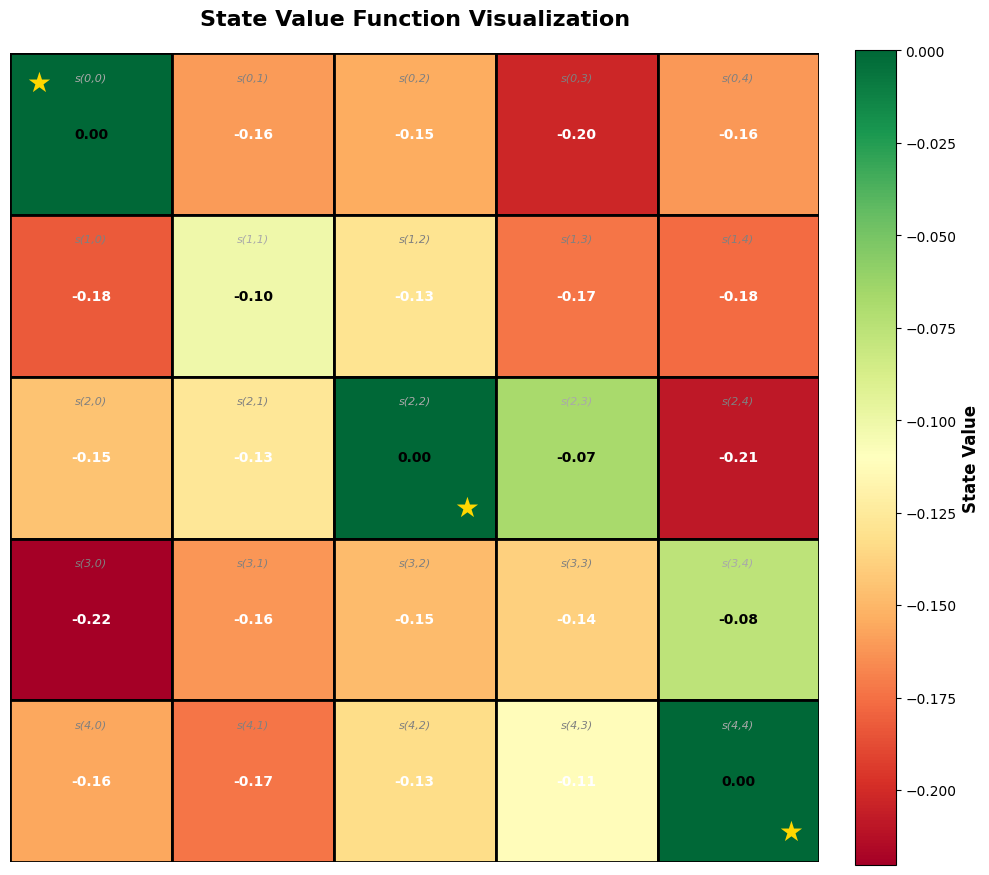

In [87]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def visualize_state_values(V_s, terminal_states=None, figsize=(10, 10), cmap='RdYlGn', show_values=True):
    """
    Visualize state values on a 5x5 grid with color coding.
    
    Parameters:
    -----------
    V_s : dict
        Dictionary with state tuples as keys and values as state values
        e.g., {(0,0): -5.2, (0,1): -4.8, ...}
    figsize : tuple
        Figure size (width, height)
    cmap : str
        Colormap name (default: 'RdYlGn' - red for low, green for high)
        Other options: 'viridis', 'plasma', 'coolwarm', 'hot', 'cool'
    show_values : bool
        Whether to display numeric values in cells
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Extract values for the grid
    grid_values = np.zeros((5, 5))
    for (row, col), value in V_s.items():
        grid_values[row, col] = value
    
    # Get min and max for normalization
    vmin = grid_values.min()
    vmax = grid_values.max()
    
    # Create colormap
    cmap_obj = plt.cm.get_cmap(cmap)
    norm = plt.cm.colors.Normalize(vmin=vmin, vmax=vmax)
    
    # Draw grid
    for row in range(5):
        for col in range(5):
            value = grid_values[row, col]
            color = cmap_obj(norm(value))
            
            # Draw rectangle
            rect = patches.Rectangle((col, 4-row), 1, 1, 
                                     linewidth=2, 
                                     edgecolor='black', 
                                     facecolor=color)
            ax.add_patch(rect)
            
            # Add text with value
            if show_values:
                text_color = 'white' if norm(value) < 0.5 else 'black'
                ax.text(col + 0.5, 4-row + 0.5, f'{value:.2f}',
                       ha='center', va='center',
                       fontsize=10, fontweight='bold',
                       color=text_color)
            
            # Add state label
            ax.text(col + 0.5, 4-row + 0.85, f's({row},{col})',
                   ha='center', va='center',
                   fontsize=8, style='italic',
                   color='gray' if norm(value) < 0.5 else 'darkgray')
    
    # Set axis properties
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Add title
    ax.set_title('State Value Function Visualization', 
                fontsize=16, fontweight='bold', pad=20)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('State Value', fontsize=12, fontweight='bold')
    
    # Add annotations for terminal states
    # Add annotations for terminal states
    for term_state in terminal_states:
        row, col = term_state
        # Position star at corner of the cell
        x_pos = col + (0.1 if col == 0 else 0.9)
        y_pos = (4 - row) + (0.9 if row == 0 else 0.1)
        h_align = 'left' if col == 0 else 'right'
        v_align = 'top' if row == 0 else 'bottom'
    
        ax.text(x_pos, y_pos, '★', ha=h_align, va=v_align, 
                fontsize=20, color='gold', zorder=10)
            
        plt.tight_layout()
    return fig, ax



V_s = state_value_function_vect(episodes=1000)
fig, ax = visualize_state_values(V_s,terminal_states=terminal_states)
plt.show()


fig.savefig('state_values_grid.png', dpi=300, bbox_inches='tight')